In [1]:
import numpy as np
import hyperspy.api as hs

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
import colorcet as cc
import stem_analysis.plot as saplot

In [3]:
from scipy.ndimage import rotate

In [4]:
%matplotlib widget

In [10]:
def PlotDiff(dp, dq, norm = 'log', cmap = cc.cm. fire, vmin_percentile = 1, vmax_percentile = 99.9):
    plt.figure(figsize = (10, 10))
    plt.subplots_adjust(0, 0.15, 1, 1)
    plt.imshow(dp, 
               norm = norm, cmap = cmap, 
               vmin = np.percentile(dp, vmin_percentile), 
               vmax = np.percentile(dp, vmax_percentile))

    ax = plt.gca()
    scalebar = ScaleBar(dq, 
                                 "1/nm",
                                 dimension = "si-length-reciprocal",
                                 location = 'lower right',
                                 frameon = False,
                                 length_fraction = 0.25,    
                                 height_fraction = 0.02,
                                 bbox_to_anchor=(1, -0.12),
                                 bbox_transform =ax.transAxes,
                                 font_properties = {'size': 32},)
    ax.add_artist(scalebar)
    ax.axis("off")
    plt.show()

In [6]:
dp_300k = hs.load("E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/300 K_1.dm4")
dp_100k = hs.load("E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/100K.dm4")
dp_5k = hs.load("E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/5K.dm4")

In [7]:
dp_300k.axes_manager, dp_100k.axes_manager, dp_5k.axes_manager

(<Axes manager, axes: (|4096, 4096)>
             Name |   size |  index |  offset |   scale |  units 
 ================ | ====== | ====== | ======= | ======= | ====== 
 ---------------- | ------ | ------ | ------- | ------- | ------ 
                x |   4096 |      0 |      -0 |   0.013 |   1/nm 
                y |   4096 |      0 |      -0 |   0.013 |   1/nm ,
 <Axes manager, axes: (|4096, 4096)>
             Name |   size |  index |  offset |   scale |  units 
 ================ | ====== | ====== | ======= | ======= | ====== 
 ---------------- | ------ | ------ | ------- | ------- | ------ 
                x |   4096 |      0 |      -0 |   0.013 |   1/nm 
                y |   4096 |      0 |      -0 |   0.013 |   1/nm ,
 <Axes manager, axes: (|4096, 4096)>
             Name |   size |  index |  offset |   scale |  units 
 ================ | ====== | ====== | ======= | ======= | ====== 
 ---------------- | ------ | ------ | ------- | ------- | ------ 
                x |   4096 | 

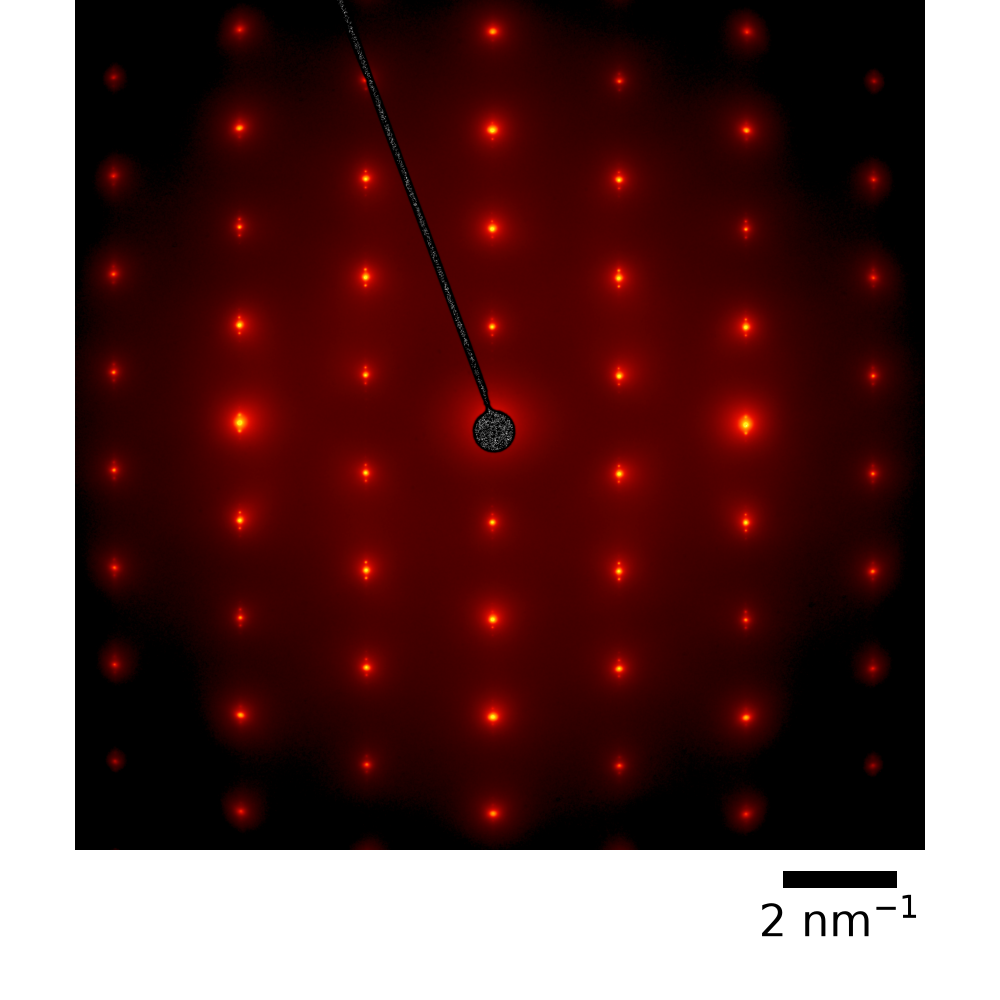

In [8]:
saplot.PlotDiff(rotate(dp_5k.data, 20)[2772-2288//2:2772+2288//2,2697 - 2288//2:2697 + 2288//2], dq = 0.013/2, cmap = cc.cm.fire,vmin_percentile = 20, vmax_percentile = 100)
#plt.savefig("E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/5K_SAED.svg", dpi = 300, transparent = True, pad_inches = 0)

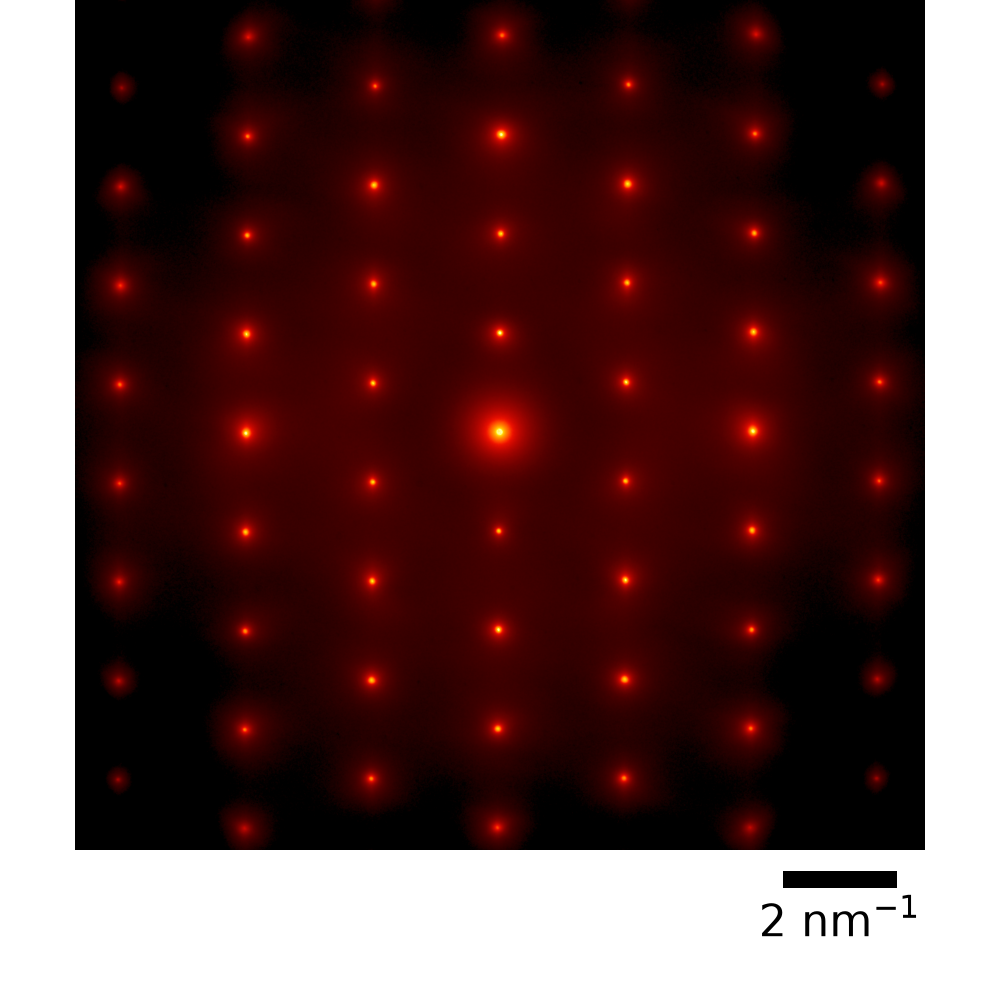

In [58]:
PlotDiff(rotate(dp_300k.data, -90+33)[2888-2288//2:2888+2288//2,2765 - 2288//2:2765 + 2288//2], dq = 0.013/2, cmap = cc.cm.fire,vmin_percentile = 20, vmax_percentile = 100)
plt.savefig("E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/300K_SAED.svg", dpi = 300, transparent = True, pad_inches = 0)

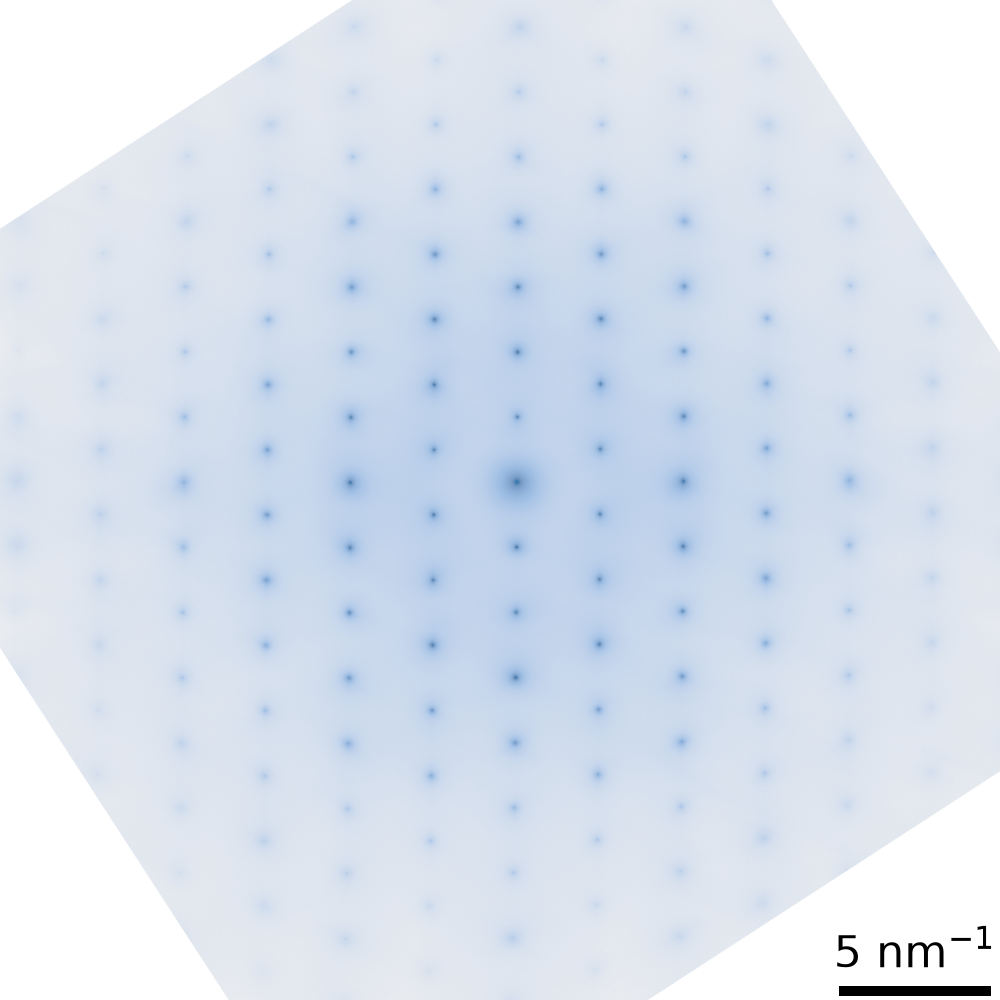

In [16]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0,0,1,1)
plt.imshow(rotate(dp_300k.data, 90+33,reshape = False), cmap=cc.cm.blues, norm='log', vmin = 3e3)
plt.axis("off")
sbar = ScaleBar(0.016/2,
                "1/nm",
                dimension = "si-length-reciprocal", 
                location = 'lower right', 
                frameon = False,
                color = 'k',
                scale_loc = 'top',
                font_properties = {'size': 32})
ax = plt.gca()
ax.add_artist(sbar)
#plt.savefig('/Users/nihy/Desktop/Working Data/CsV3Sb5/SAED/300K_OneView.svg', dpi=300, bbox_inches='tight', pad_inches=0)

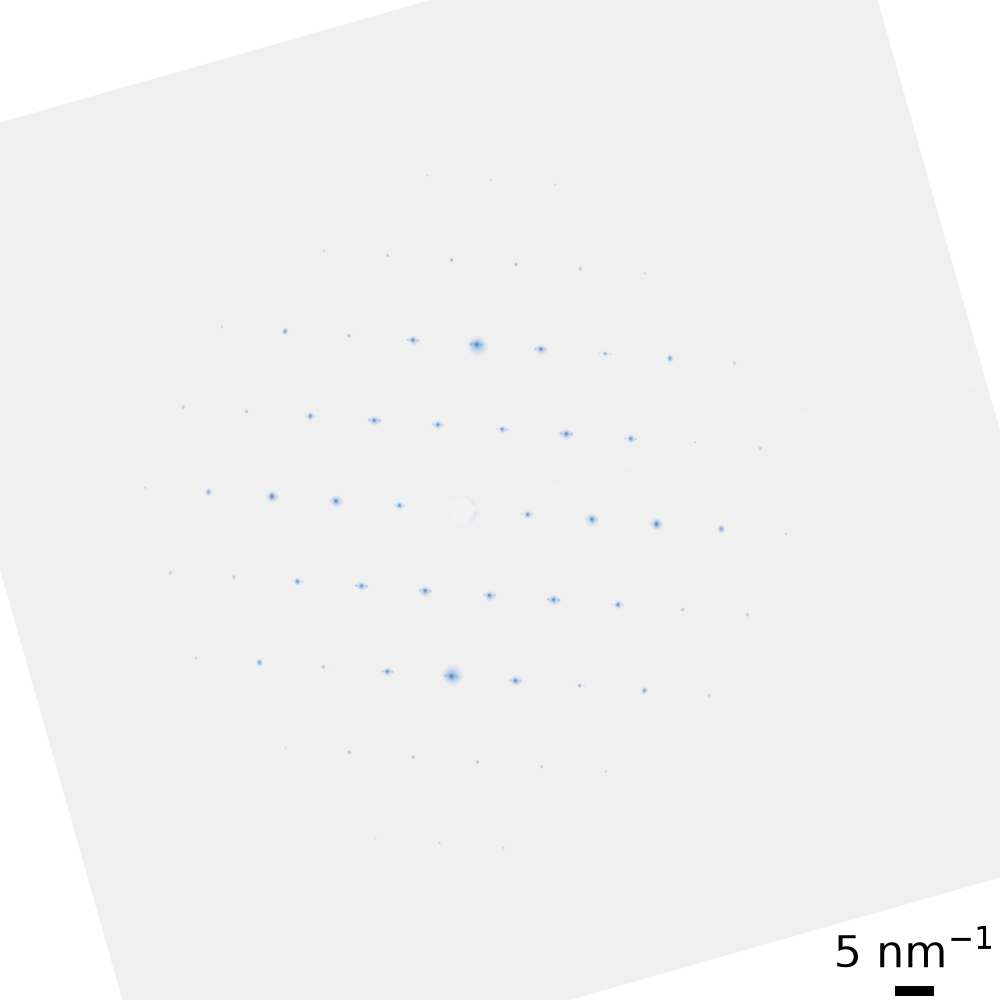

In [8]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0,0,1,1)
plt.imshow(rotate(dp_5k.data, -164.14+90,reshape = False), cmap=cc.cm.blues, norm='log', vmin = 1e5, vmax = 1e7)
plt.axis("off")
sbar = ScaleBar(0.063/2,
                "1/nm",
                fixed_value = 5,
                dimension = "si-length-reciprocal", 
                location = 'lower right', 
                frameon = False,
                color = 'k',
                scale_loc = 'top',
                font_properties = {'size': 32})
ax = plt.gca()
ax.add_artist(sbar)
#plt.savefig('/Users/nihy/Desktop/Working Data/CsV3Sb5/SAED/5K_stela.svg', dpi=300, bbox_inches='tight', pad_inches=0)

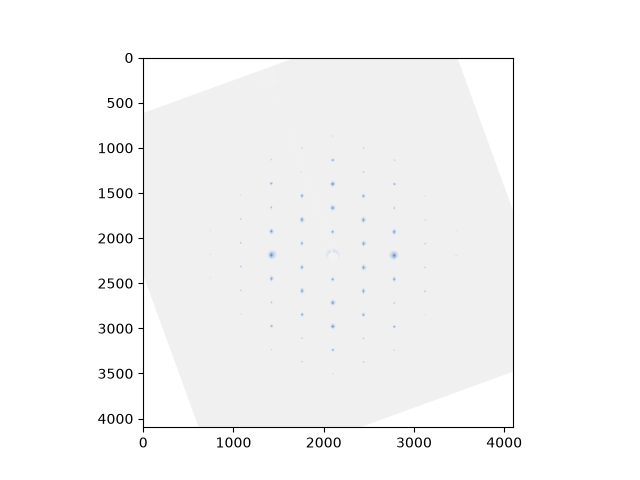

In [9]:
plt.figure()
plt.imshow(rotate(dp_5k.data, 20,reshape = False), cmap=cc.cm.blues, norm='log', vmin=7e4)

In [17]:
line_profile_5k = rotate(dp_5k.data, 20,reshape = False)[2194 - 100: 2194 + 100, 2780 -5 : 2780 + 5].mean(1)
line_profile_100k = rotate(dp_100k.data, -66.1,reshape = False)[2120 - 100: 2120 + 100, 2586 -5 : 2586 + 5].mean(1)
line_profile_300k = rotate(dp_300k.data, 90+33,reshape = False)[1970 - 100: 1970 + 100, 2800 -5 : 2800 + 5].mean(1)

In [18]:
x = np.arange(-100, 100)*0.013/2
#x1 = np.arange(-100, 100)*0.012/2

In [26]:
n_lines = 3
cmap = mpl.colormaps['plasma']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 3))

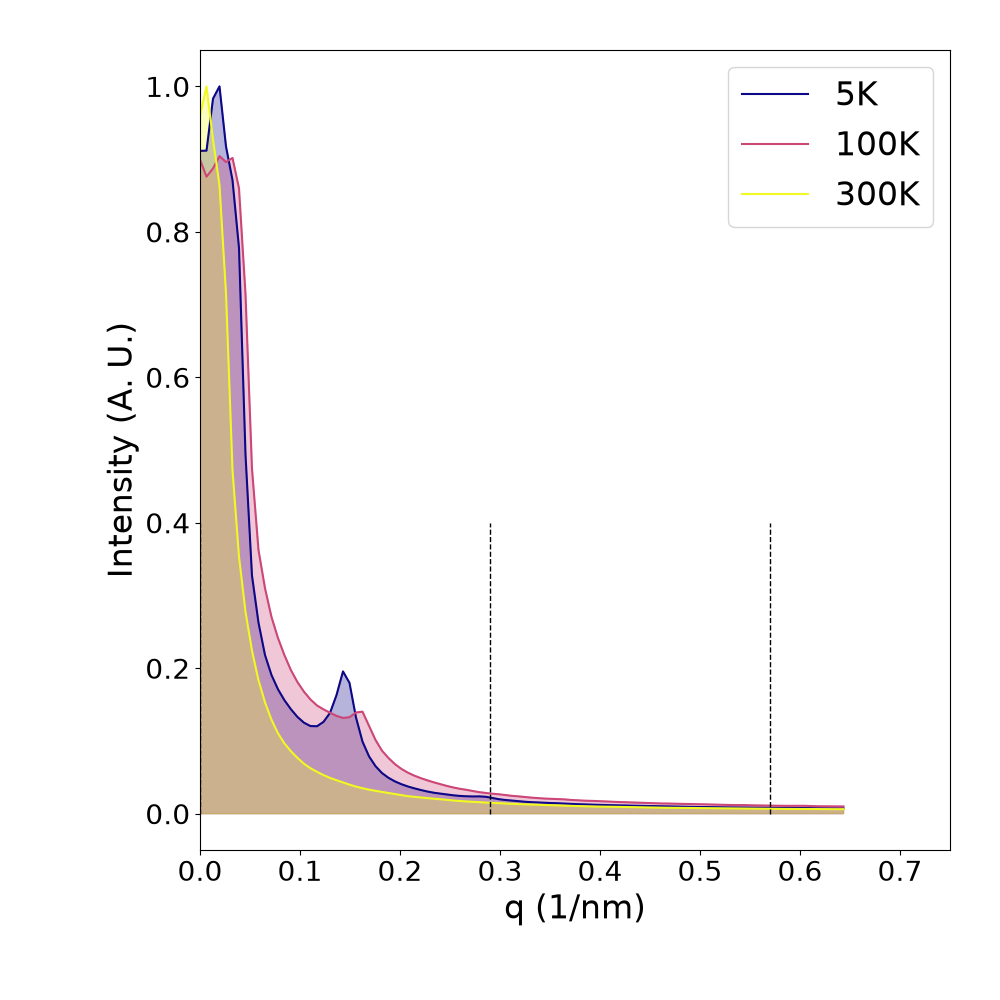

In [27]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0.2, 0.15, 0.95, 0.95)
plt.plot(x, line_profile_5k/line_profile_5k.max(), label='5K', color = colors[0])
plt.fill_between(x, line_profile_5k/line_profile_5k.max(), alpha=0.3, color = colors[0])
plt.plot(x, line_profile_100k/line_profile_100k.max(), label='100K', color = colors[1])
plt.fill_between(x, line_profile_100k/line_profile_100k.max(), alpha=0.3, color = colors[1])
plt.plot(x, line_profile_300k/line_profile_300k.max(), label='300K', color = colors[2])
plt.fill_between(x, line_profile_300k/line_profile_300k.max(), alpha=0.3, color = colors[2])

plt.legend(fontsize = 24)
plt.xlim(0, 0.75)
#plt.ylim(0, 0.4)
plt.xlabel('q (1/nm)', fontsize = 24)
plt.ylabel('Intensity (A. U.)', fontsize = 24)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.vlines([0, 0.29, 0.57], 0, 0.4, color = 'k', ls = '--', lw = 1)

#plt.savefig('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/intensity_200.svg', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Haoyang Ni\AppData\Local\Temp\ipykernel_56508\4283992685.py:15: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$I\cdot q^2$', fontsize = 32)
C:\Users\Haoyang Ni\AppData\Local\Temp\ipykernel_56508\4283992685.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (20, 10))


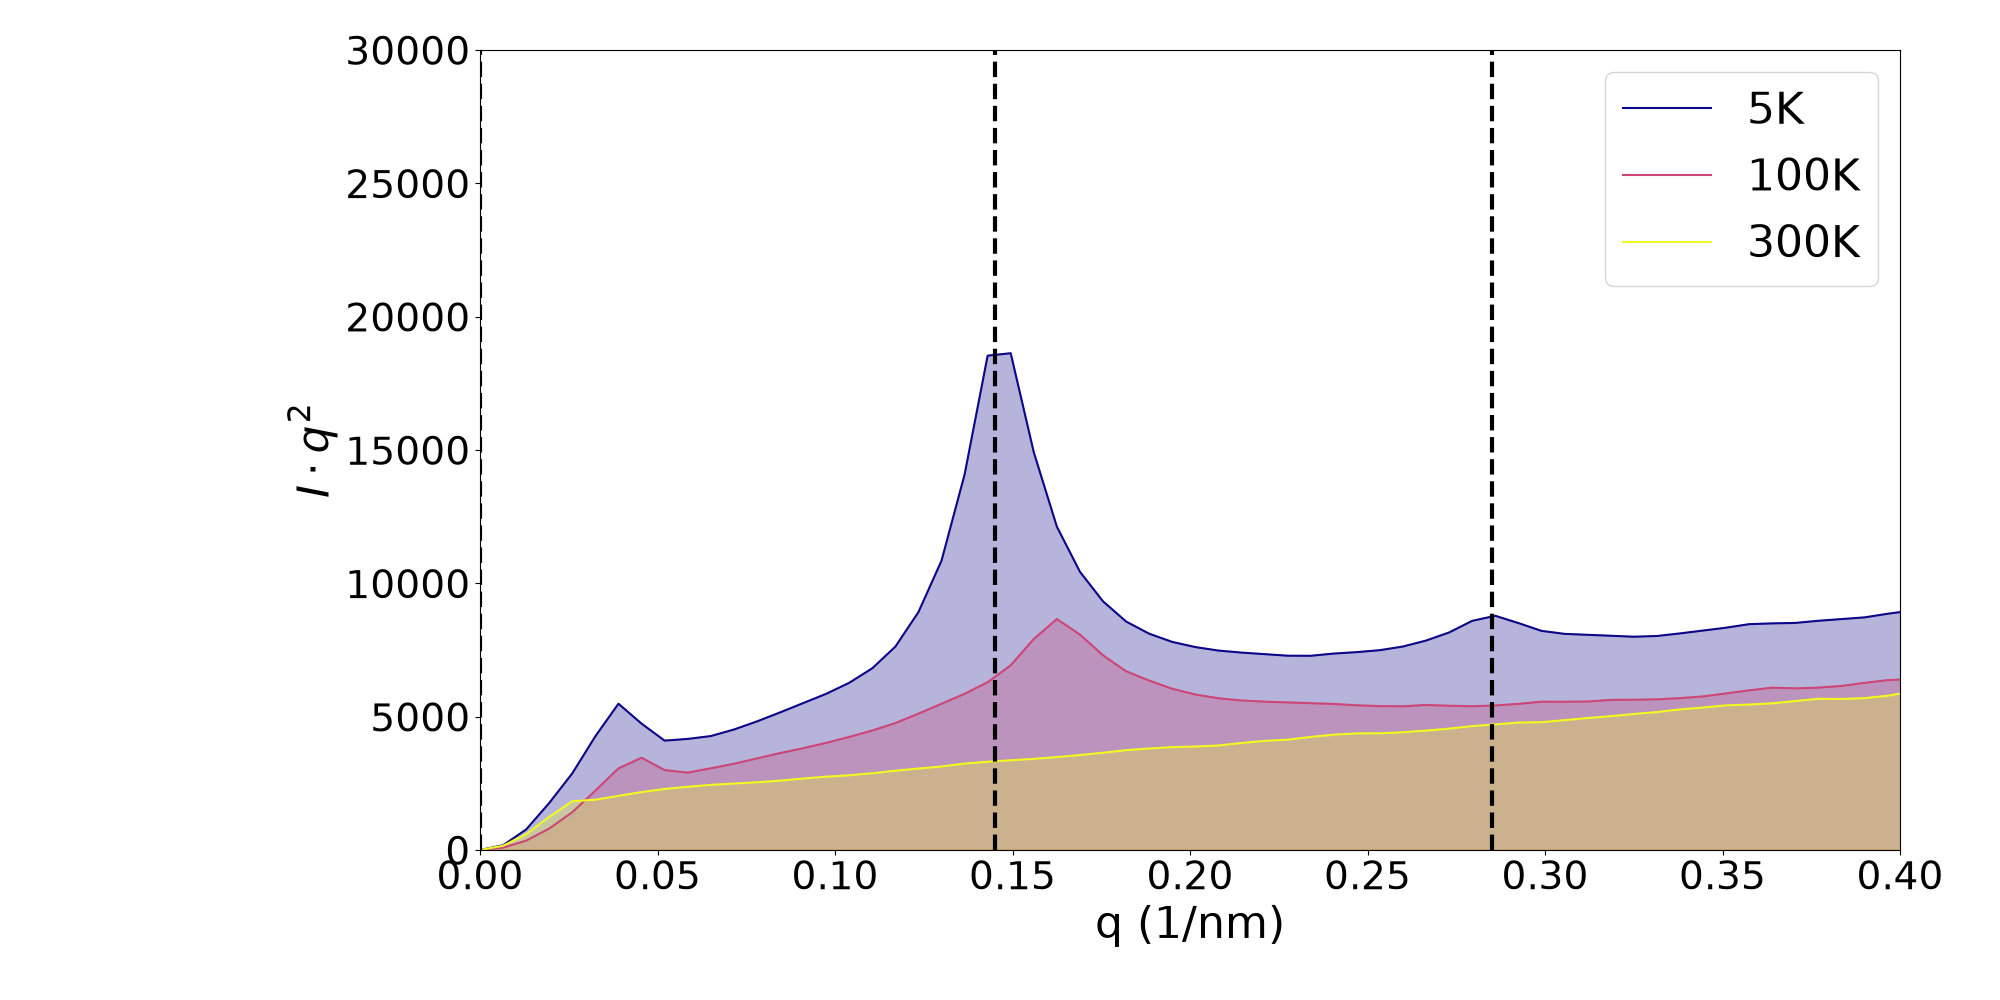

In [42]:
plt.figure(figsize = (20, 10))
plt.subplots_adjust(0.24, 0.15, 0.95, 0.95)
plt.plot(x, line_profile_5k*x**2, label='5K', color = colors[0])
plt.fill_between(x, line_profile_5k*x**2, alpha=0.3, color = colors[0])
plt.plot(x, line_profile_100k*x**2, label='100K', color = colors[1])
plt.fill_between(x, line_profile_100k*x**2, alpha=0.3, color = colors[1])
plt.plot(x, line_profile_300k*x**2, label='300K', color = colors[2])
plt.fill_between(x, line_profile_300k*x**2, alpha=0.3, color = colors[2])


plt.legend(fontsize = 32)
plt.xlim(0, 0.4)
plt.ylim(0, 3e4)
plt.xlabel('q (1/nm)', fontsize = 32)
plt.ylabel('$I\cdot q^2$', fontsize = 32)
plt.tick_params(axis='both', which='major', labelsize=28)
plt.vlines([0, 0.29/2, 0.57/2], 0, 1e6, color = 'k', ls = '--', lw = 3)
plt.savefig('E:/EuAl4 Chiral/Good Data/SAED/Temp Dependence/intensity_q2_200.svg', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)

In [49]:
img_abf_100 = hs.load("E:/EuAl4 Chiral/Good Data/STEM/300 K_ABF_100.dm4")
img_abf_100.axes_manager

Signal axis name,size,,offset,scale,units
x,398,,2.0363824367523193,0.01257026195526123,nm
y,398,,3.5196733474731445,0.01257026195526123,nm


In [52]:
img_abf_001 = hs.load("E:/EuAl4 Chiral/Good Data/STEM/300 K_ABF_001.dm4")
img_abf_001.axes_manager

Signal axis name,size,,offset,scale,units
x,398,,2.224936366081238,0.01257026195526123,nm
y,398,,1.4958611726760864,0.01257026195526123,nm


In [44]:
def PlotImage(image, dr, cmap = 'gray', vmin_percentile = 1, vmax_percentile = 99):
    plt.figure(figsize = (10, 10))
    plt.imshow(image, cmap = cmap, vmin = np.percentile(image, vmin_percentile), vmax = np.percentile(image, vmax_percentile))
    ax = plt.gca()
    ax.axis('off')
    scalebar = ScaleBar(dr, 
                                     "nm",
                                     dimension = "si-length",
                                     location = 'lower right',
                                     frameon = False,
                                     length_fraction = 0.25,    
                                     height_fraction = 0.02,
                                     bbox_to_anchor=(1, -0.12),
                                     bbox_transform =ax.transAxes,
                                     font_properties = {'size': 32},)
    ax.add_artist(scalebar)
    ax.axis("off")
    plt.show()


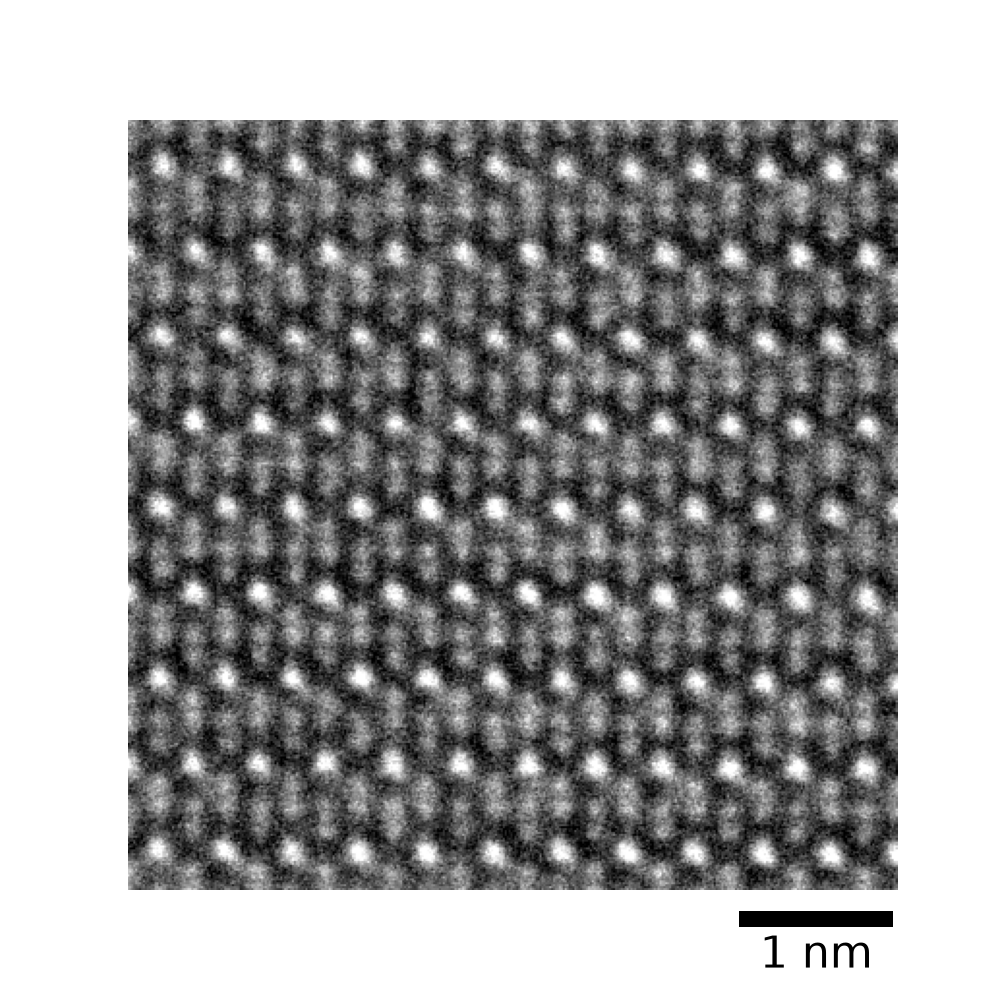

In [51]:
PlotImage(img_abf_100.data, img_abf_100.axes_manager[0].scale, cmap = 'gray_r')
plt.savefig("E:/EuAl4 Chiral/Good Data/STEM/300 K_ABF_100.svg", dpi = 300, pad_inches = 0, transparent = True)

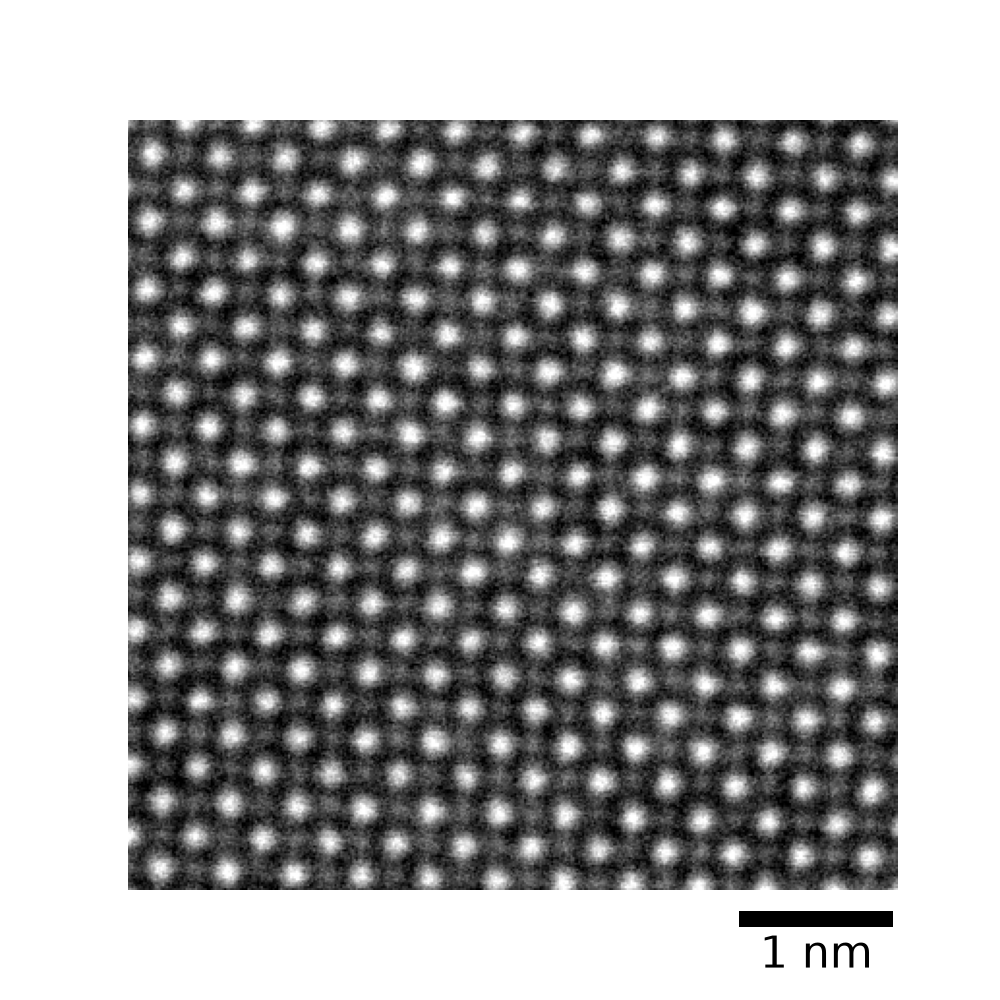

In [53]:
PlotImage(img_abf_001.data, img_abf_001.axes_manager[0].scale, cmap = 'gray_r')
plt.savefig("E:/EuAl4 Chiral/Good Data/STEM/300 K_ABF_001.svg", dpi = 300, pad_inches = 0, transparent = True)